In [12]:
!pip3 install pandas numpy matplotlib scikit-learn


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
import math
import random

In [2]:
# Đọc dữ liệu
df = pd.read_csv("customer_data1.csv")
print(df.head())

   id  age  gender  income   education region loyalty_status  \
0   1   27    Male   40682    Bachelor   East           Gold   
1   2   29    Male   15317     Masters   West        Regular   
2   3   37    Male   38849    Bachelor   West         Silver   
3   4   30    Male   11568  HighSchool  South        Regular   
4   5   31  Female   46952     College  North        Regular   

  purchase_frequency  purchase_amount product_category  satisfaction_score  
0           frequent            18249            Books                   6  
1               rare             4557         Clothing                   6  
2               rare            11822         Clothing                   6  
3           frequent             4098             Food                   7  
4         occasional            19685         Clothing                   5  


In [3]:
df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['id']).head(10000)
print(df.head())

   age  income  purchase_amount  satisfaction_score
0   27   40682            18249                   6
1   29   15317             4557                   6
2   37   38849            11822                   6
3   30   11568             4098                   7
4   31   46952            19685                   5


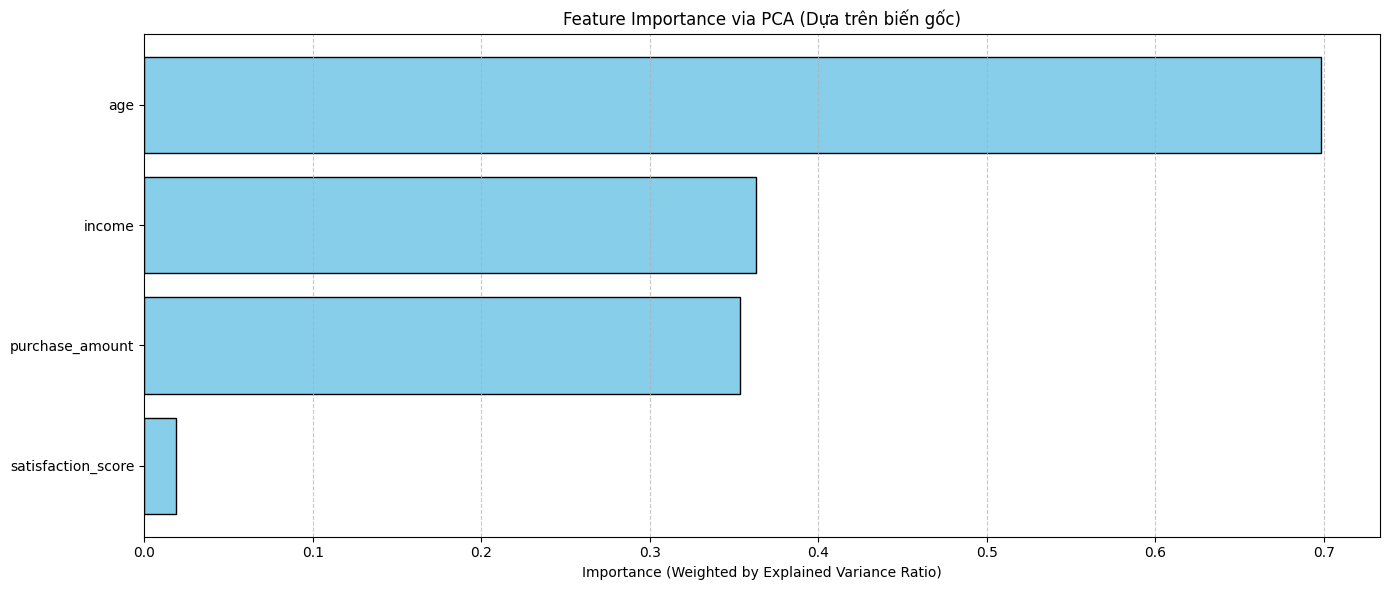

In [4]:
# Bước 1: PCA đầy đủ (full component)
df_encoded = df
categorical_num_cols = ['age','income','purchase_amount','satisfaction_score']  

scaler = StandardScaler()
df_encoded[categorical_num_cols] = scaler.fit_transform(df_encoded[categorical_num_cols])

pca = PCA()
X_pca = pca.fit_transform(df_encoded)

# Bước 2: Tính ma trận loading
loadings = pca.components_.T  # shape: (n_features, n_components)

# Bước 3: Tính importance của từng biến gốc
# Tổng tỉ trọng (weighted loading) trên tất cả các thành phần chính
importance_weighted = np.sum(
    (np.abs(loadings).T * pca.explained_variance_ratio_).T, axis=1
)

# Bước 4: Đưa vào DataFrame
feature_importance = pd.DataFrame({
    'Feature': df.columns,
    'Importance': importance_weighted
}).sort_values(by='Importance', ascending=True)

# Bước 5: Vẽ biểu đồ
plt.figure(figsize=(14, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='skyblue', edgecolor='black')
plt.xlabel("Importance (Weighted by Explained Variance Ratio)")
plt.title("Feature Importance via PCA (Dựa trên biến gốc)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Biến sẽ bị loại bỏ: ['satisfaction_score']
        age    income  purchase_amount
0 -0.667454  1.014020         1.811069
1 -0.220727 -0.942540        -1.061468
2  1.566178  0.872629         0.462705
3  0.002636 -1.231724        -1.157765
4  0.225999  1.497664         2.112337
[[ 2.01051104 -0.62800884]
 [-1.41238282 -0.24878384]
 [ 0.91291559  1.58482527]
 ...
 [-0.87472944 -0.68483293]
 [ 0.81941675  1.13601337]
 [ 1.5712904  -0.63639209]]


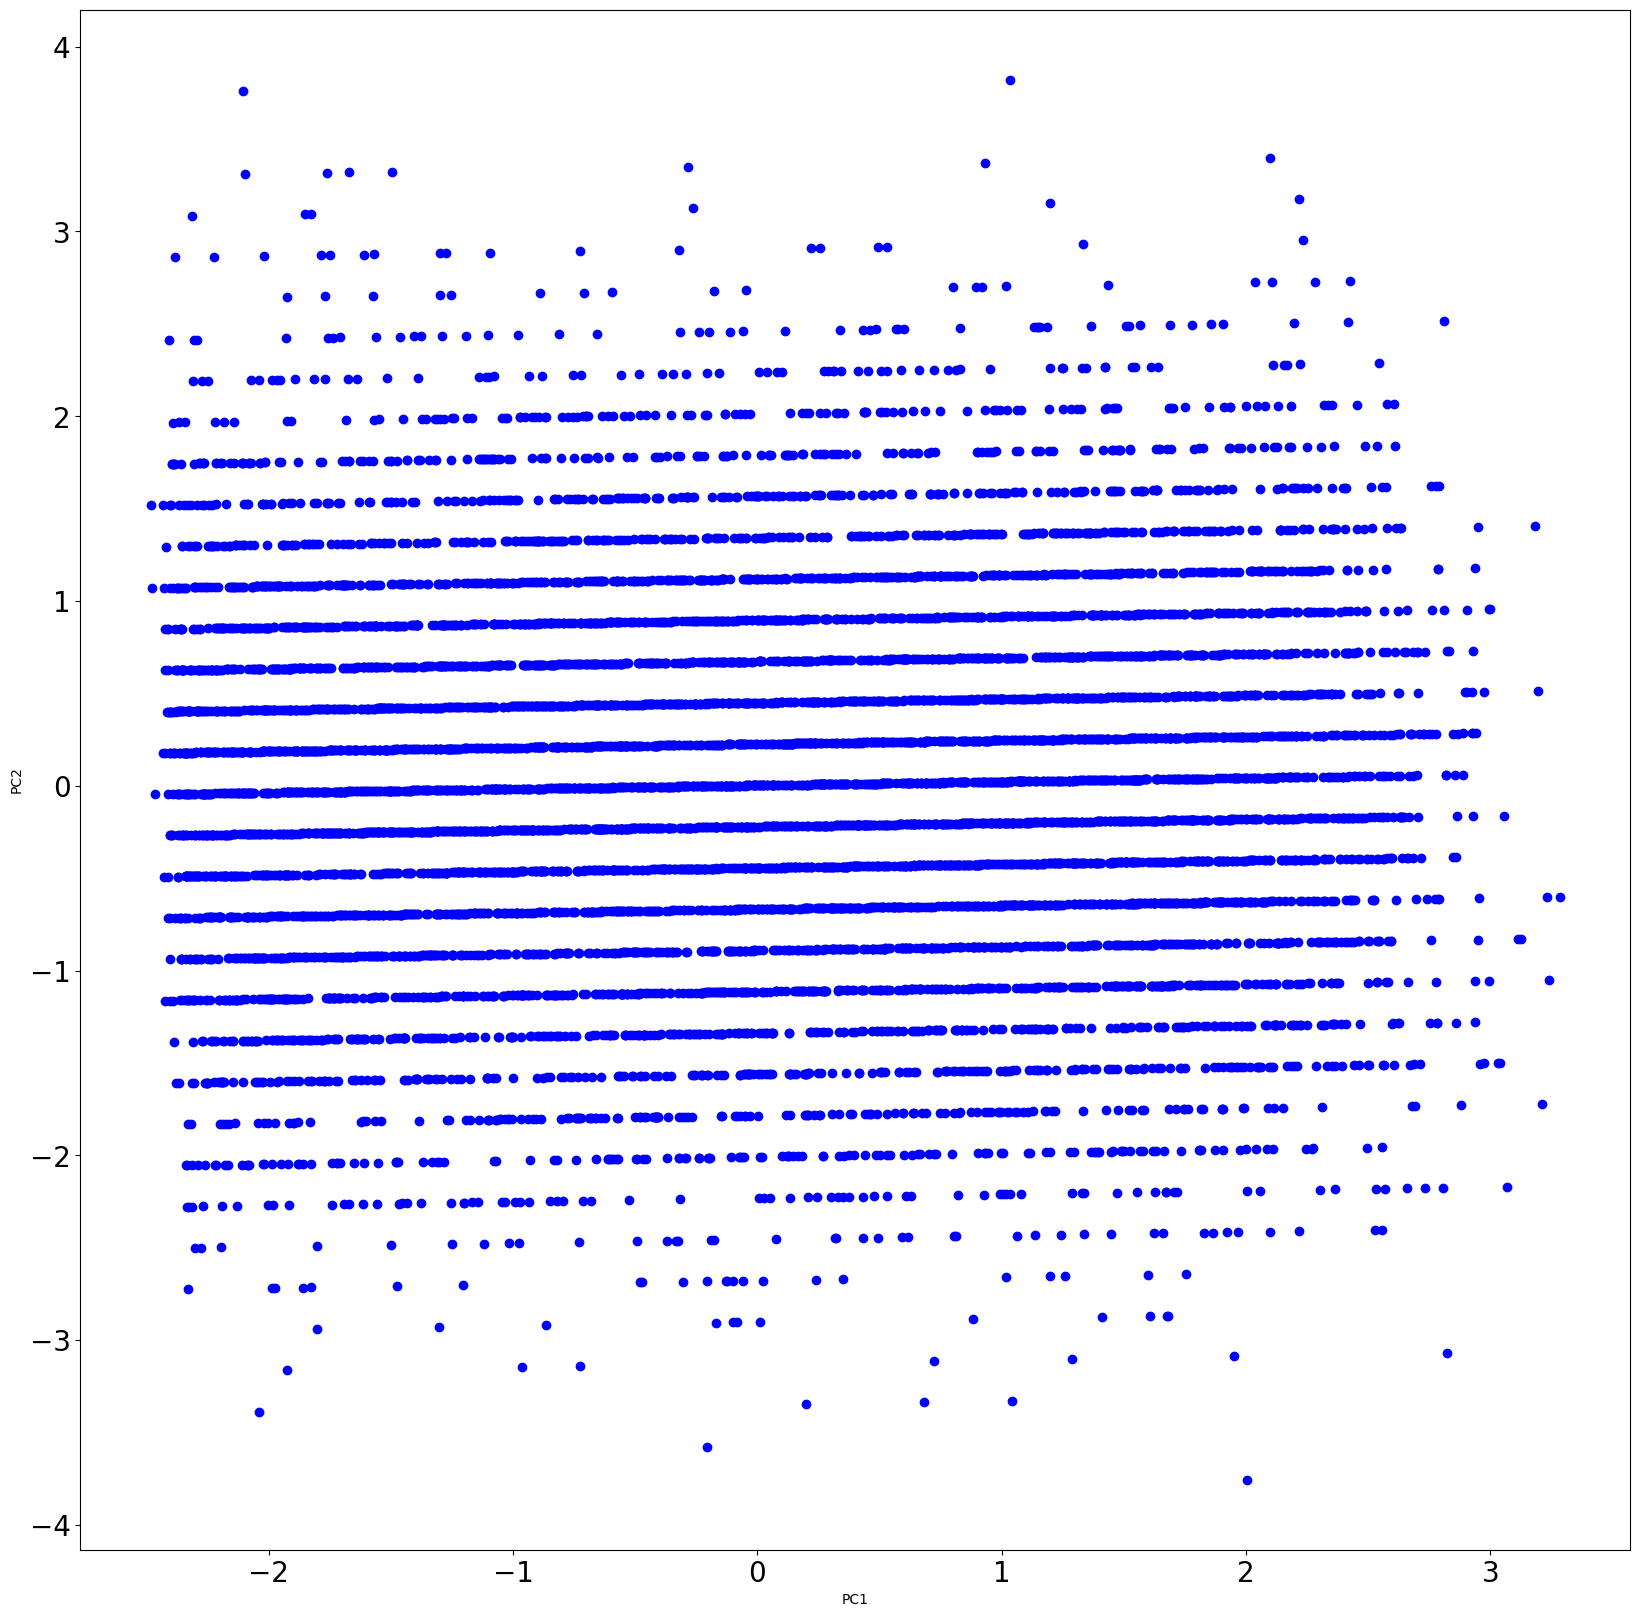

In [5]:
threshold = 0.2
low_importance_features = df.columns[importance_weighted < threshold]
print("Biến sẽ bị loại bỏ:", list(low_importance_features))

df_new = df_encoded.drop(columns=low_importance_features)
print(df_new.head())

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_new)
print(X_pca)

plt.figure(figsize=(20, 20))
plt.scatter(X_pca[:,0], X_pca[:,1], color='b')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [6]:
# Point
class Point:
    def __init__(self, coordinate):
        self.coordinate = coordinate
        self.cluster_idx = None

    def is_clustered(self):
        return self.cluster_idx is not None

    def cluster(self, cluster_idx):
        self.cluster_idx = cluster_idx


# DBSCAN from scratch
class DBSCAN:
    def __init__(self, epsi, min_points):
        self.epsi = epsi
        self.min_points = min_points
        self.labels_ = None

    @staticmethod
    def _compute_distance(x1, x2):
        return math.sqrt(np.sum(np.power(np.subtract(x1, x2), 2)))  # Khoảng cách Euclidean

    def _find_neighbor_indices(self, core_point, points):
        neighbor_indices = []
        for idx, other_point in enumerate(points):
            if self._compute_distance(core_point.coordinate, other_point.coordinate) <= self.epsi:
                neighbor_indices.append(idx)
        return neighbor_indices

    def fit(self, df, feature_cols):
        points = []
        for _, row in df[feature_cols].iterrows():
            points.append(Point(row.to_numpy()))

        free_point_indices = set(range(len(points)))
        cluster_count = 0

        while free_point_indices:
            current_idx = random.choice(list(free_point_indices))
            current_point = points[current_idx]
            neighbors = self._find_neighbor_indices(current_point, points)

            if len(neighbors) < self.min_points:
                current_point.cluster(-1)  # Noise
                free_point_indices.remove(current_idx)
            else:
                cluster_count += 1
                points[current_idx].cluster(cluster_count)
                free_point_indices.remove(current_idx)

                core_queue = neighbors.copy()
                while core_queue:
                    neighbor_idx = core_queue.pop()
                    neighbor_point = points[neighbor_idx]

                    if not neighbor_point.is_clustered():
                        neighbor_point.cluster(cluster_count)
                        free_point_indices.discard(neighbor_idx)

                        neighbor_neighbors = self._find_neighbor_indices(neighbor_point, points)
                        if len(neighbor_neighbors) >= self.min_points:
                            core_queue.extend(neighbor_neighbors)

        self.labels_ = np.array([p.cluster_idx for p in points])
        return self

In [7]:
def davies_bouldin_index(X, labels):
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return np.nan

    unique_labels = unique_labels[unique_labels != -1]
    k = len(unique_labels)
    centroids = []
    S = []

    for label in unique_labels:
        cluster_points = X[labels == label]
        centroid = np.mean(cluster_points, axis=0)
        centroids.append(centroid)
        dispersion = np.mean(np.linalg.norm(cluster_points - centroid, axis=1))
        S.append(dispersion)

    centroids = np.array(centroids)
    S = np.array(S)
    M = pairwise_distances(centroids)

    dbi = 0.0
    for i in range(k):
        max_ratio = -np.inf
        for j in range(k):
            if i != j:
                ratio = (S[i] + S[j]) / M[i][j]
                if ratio > max_ratio:
                    max_ratio = ratio
        dbi += max_ratio

    return dbi / k

        age    income  purchase_amount
0 -0.667454  1.014020         1.811069
1 -0.220727 -0.942540        -1.061468
2  1.566178  0.872629         0.462705
3  0.002636 -1.231724        -1.157765
4  0.225999  1.497664         2.112337


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


epsilon = 0.30000000000000004 
min_samples = 20 
số cụm = 1 
Davies-Bouldin Index thấp nhất= -inf


posx and posy should be finite values
posx and posy should be finite values


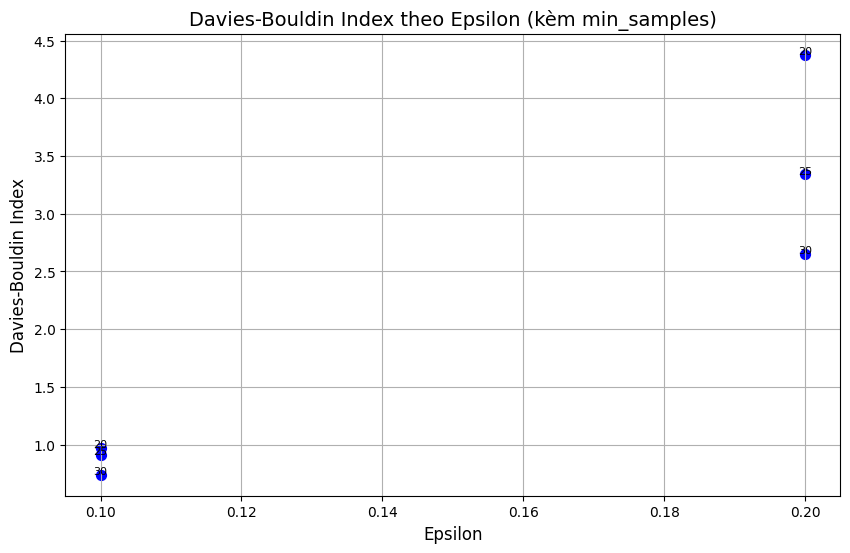

In [8]:
epsilon = np.arange(0.1, 0.31, 0.1) 
min_samples = list(range(20, 31, 5))

sil_avg = []
min_value = [0,0,0,float('inf')]

new_features = ['age','purchase_amount','income']

print(df_new.head())

for eps in epsilon:
    for min_s in min_samples:
        db = DBSCAN(min_points = min_s, epsi =eps).fit(df_new, new_features)
        labels = db.labels_

        # Number of clusters in labels, ignoring noise if present.
        n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise_ = list(labels).count(-1)

        db_index = davies_bouldin_index(df_new, labels)
        if db_index < min_value[3]:
            min_value=(eps, min_s, n_clusters_, db_index)
        sil_avg.append(db_index)


print("epsilon =", min_value[0], 
      "\nmin_samples =", min_value[1],
      "\nsố cụm =", min_value[2],
      "\nDavies-Bouldin Index thấp nhất= %.4f" % min_value[3])
# Vẽ biểu đồ Silhouette Score theo eps và min_samples
sil_avg_array = np.array(sil_avg).reshape(len(epsilon), len(min_samples))

# Tạo scatter plot
plt.figure(figsize=(10, 6))
for i in range(len(epsilon)):
    for j in range(len(min_samples)):
        plt.scatter(epsilon[i], sil_avg_array[i][j], 
                    c='blue', s=50)
        plt.text(epsilon[i], sil_avg_array[i][j]+0.005, 
                 f'{min_samples[j]}', fontsize=8, ha='center')

plt.title('Davies-Bouldin Index theo Epsilon (kèm min_samples)', fontsize=14)
plt.xlabel('Epsilon', fontsize=12)
plt.ylabel('Davies-Bouldin Index', fontsize=12)
plt.grid(True)
plt.show()

In [9]:
X_pca_new = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
new_col = ['PC1','PC2']
print(X_pca_new.head())

db = DBSCAN(eps=0.1, min_samples=25).fit(X_pca_new)
labels = db.labels_

# Number of clusters in labels, ignoring noise.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)


print('Số cụm: %d' % n_clusters_)
print('Số điểm nhiễu: %d' % n_noise_)
print("DBIndex: %0.3f"
      % davies_bouldin_index(X_pca_new, labels))

        PC1       PC2
0  2.010511 -0.628009
1 -1.412383 -0.248784
2  0.912916  1.584825
3 -1.689342 -0.030973
4  2.547664  0.276382


TypeError: DBSCAN.__init__() got an unexpected keyword argument 'eps'

C:\Users\levie\AppData\Local\Temp\ipykernel_25432\496960036.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_labels))


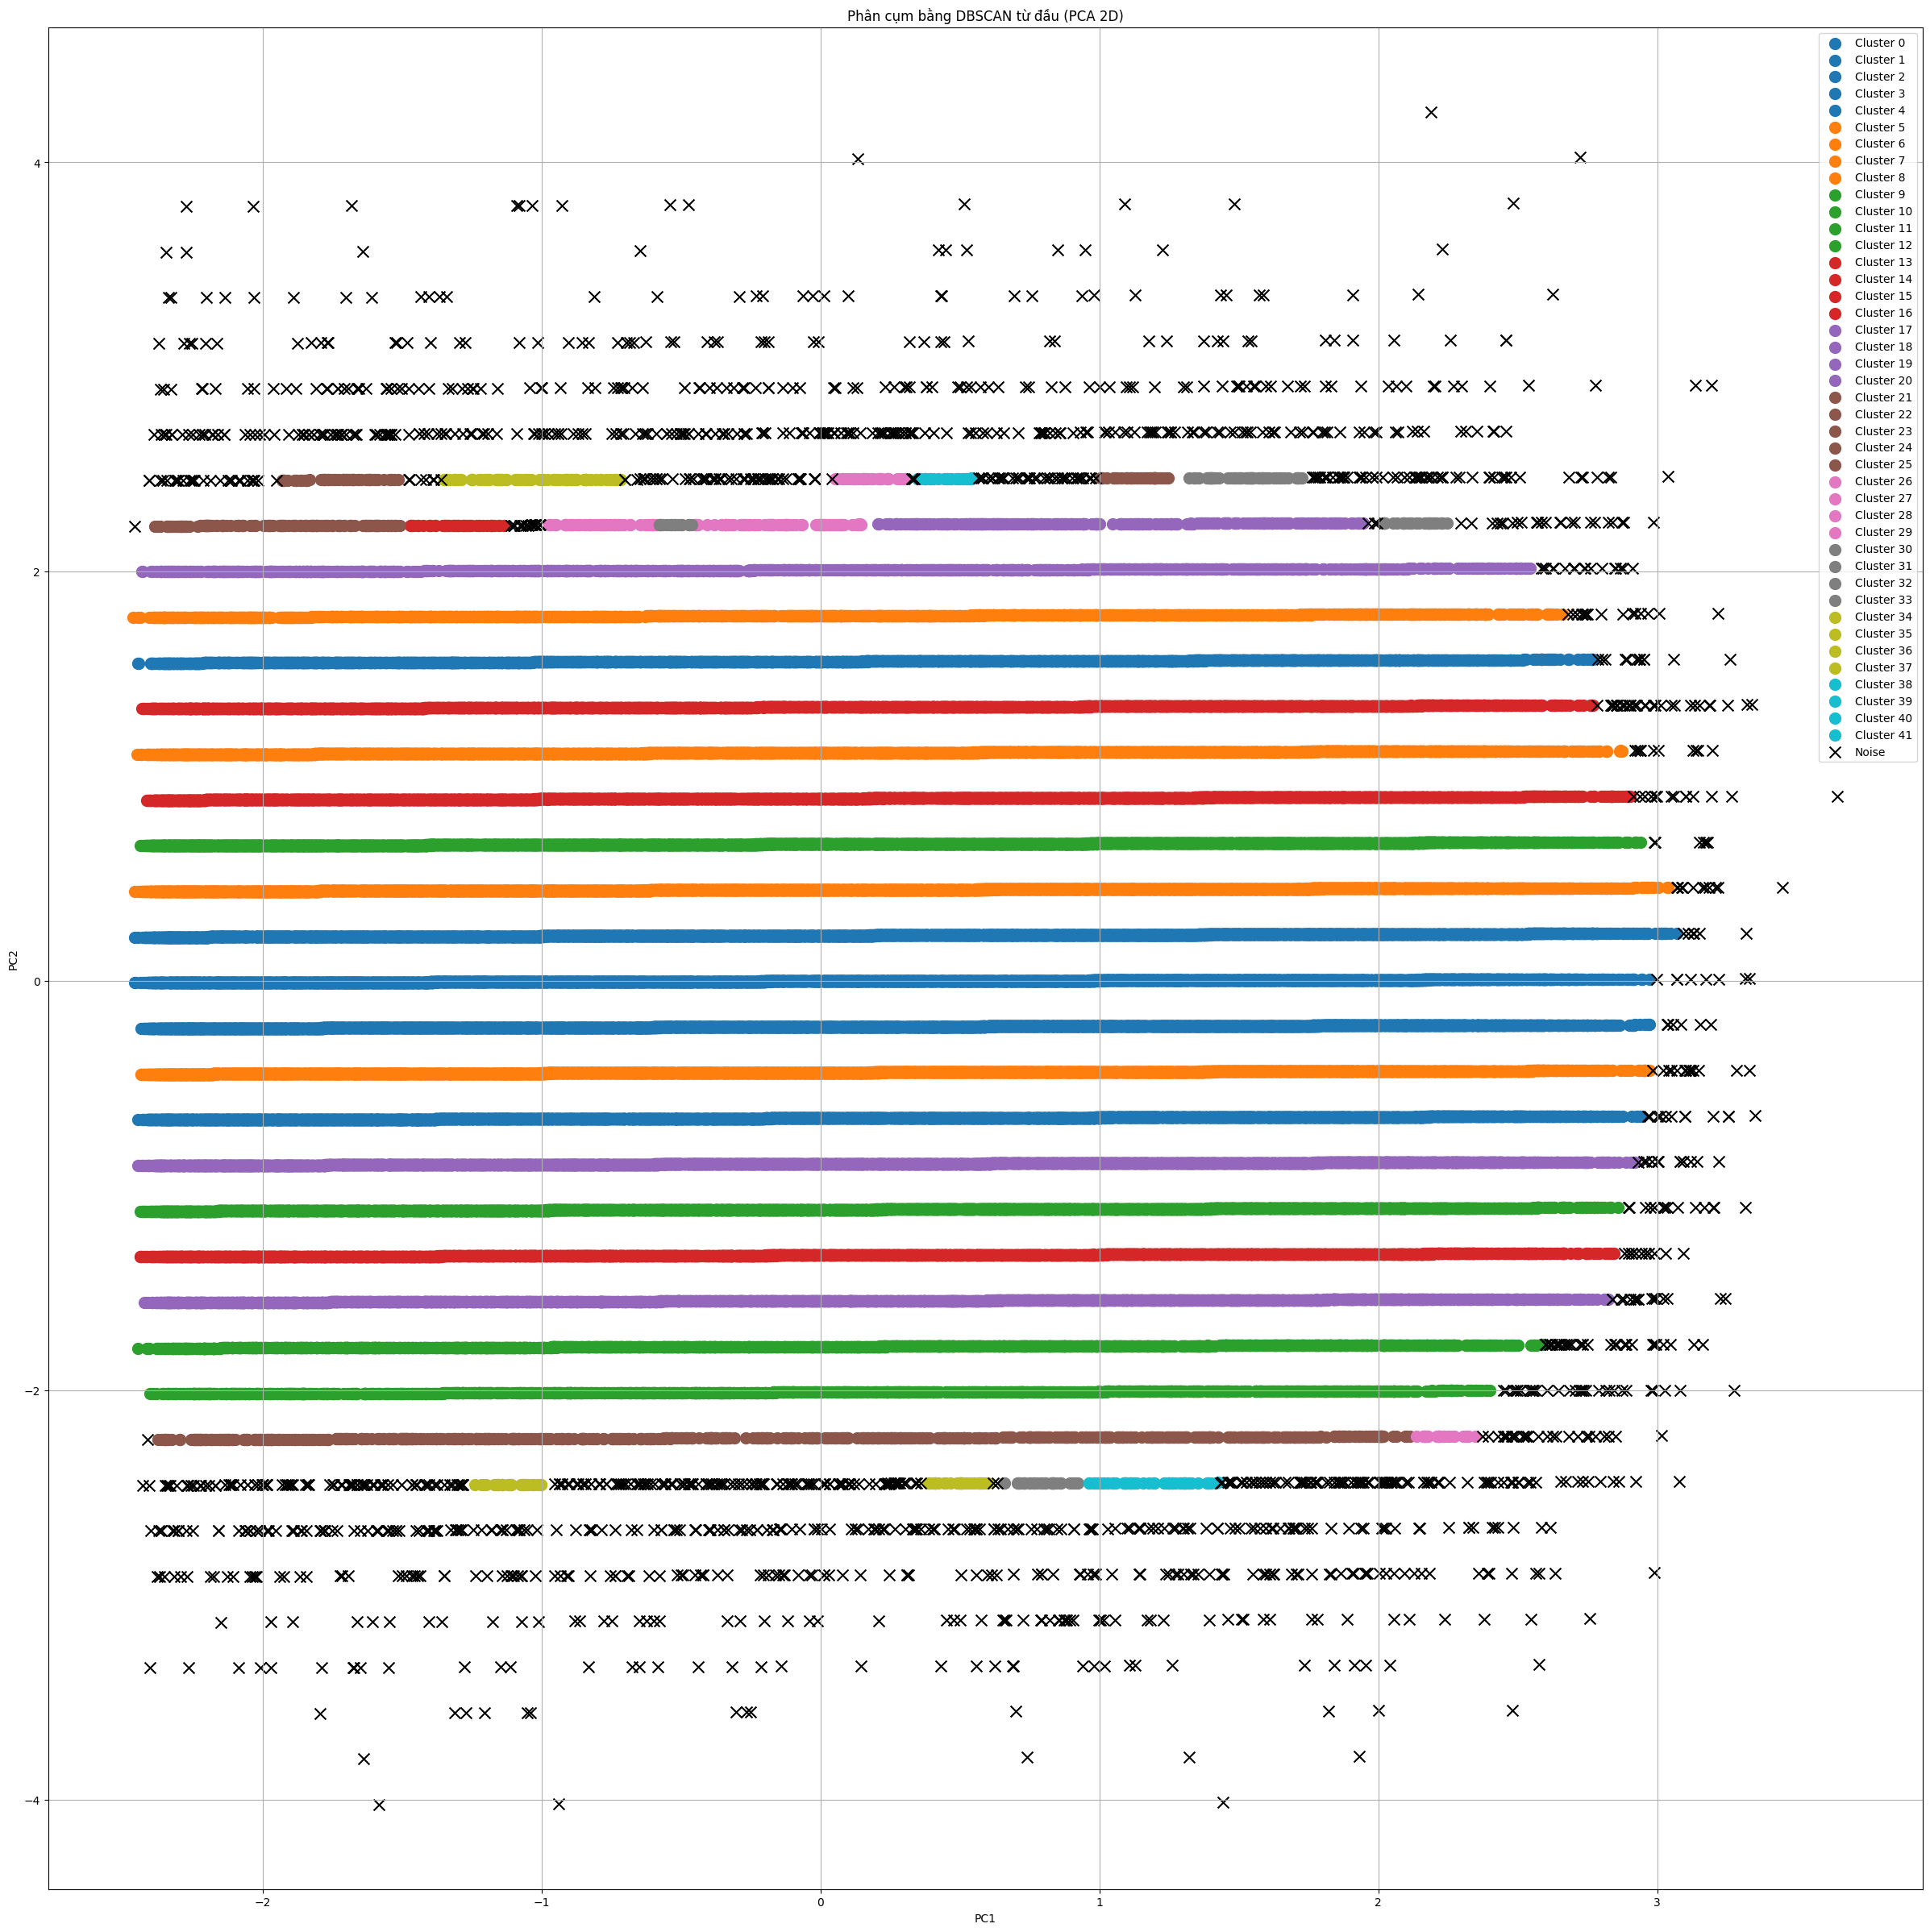

In [ ]:
labels = db.labels_
unique_labels = set(labels)
colors = plt.cm.get_cmap("tab10", len(unique_labels))

plt.figure(figsize=(30,30))
for k in unique_labels:
    cluster_mask = (labels == k)
    xy = X_pca[cluster_mask]
    
    if k == -1:
        plt.scatter(xy[:, 0], xy[:, 1], s=100, c='black', marker='x', label='Noise')
    else:
        plt.scatter(xy[:, 0], xy[:, 1], s=100, c=[colors(k)], label=f'Cluster {k}')

plt.title("Phân cụm bằng DBSCAN từ đầu (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()